In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt


In [100]:
df=pd.read_csv("netflix_titles.csv")



In [101]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [102]:
df = df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'rating': 'Unknown'
})

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Missing values after cleaning:\n", df.isnull().sum())
print("\nMovies vs TV Shows:")
print(df['type'].value_counts())

Missing values after cleaning:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      98
month_added     98
dtype: int64

Movies vs TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


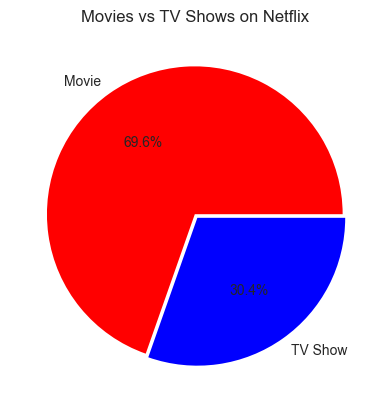

In [103]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.pie(type_counts.values,
        labels=type_counts.index,
        autopct='%1.1f%%',
        colors=['red', 'blue'],
        explode=[0,0.03])

plt.title('Movies vs TV Shows on Netflix')
plt.show()

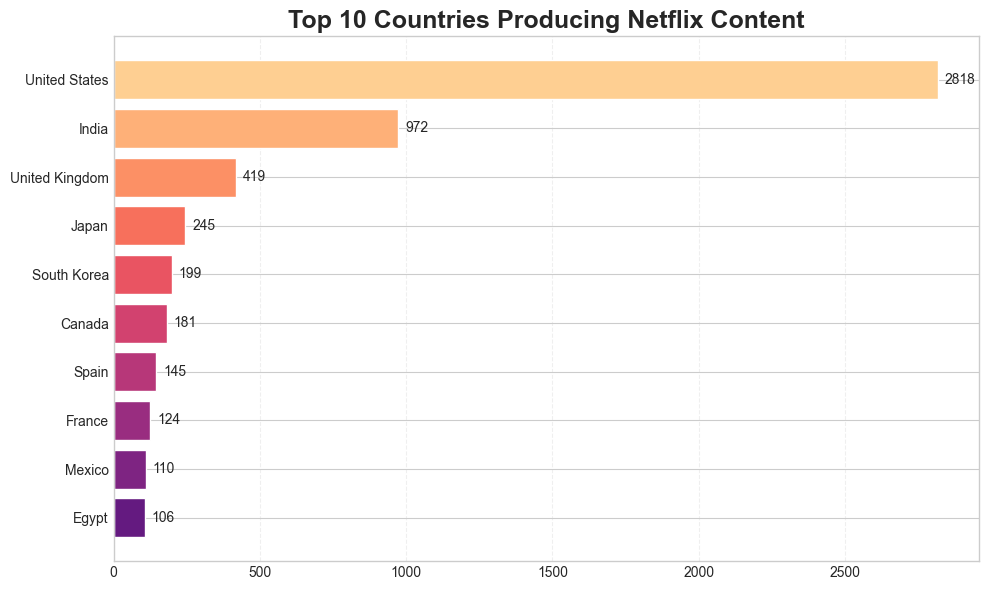

In [104]:
top_countries = (
    df[df['country'] != 'Unknown']['country'].value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    top_countries.index,
    top_countries.values,
    color=cm.magma(np.linspace(0.3,0.9,len(top_countries))),
    edgecolor='white'
)

ax.bar_label(bars, padding=5)
ax.set_title("Top 10 Countries Producing Netflix Content", fontsize=18, weight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

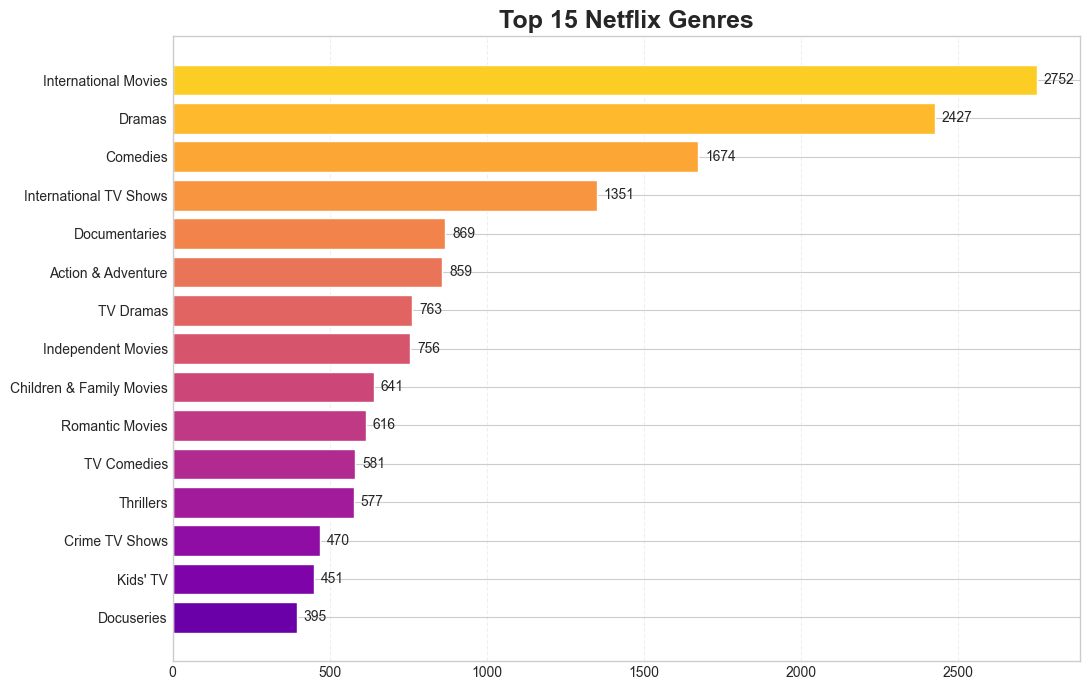

In [105]:
top_genres = (
    df['listed_in'].str.split(', ').explode().value_counts().head(15).sort_values()
)
fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(
    top_genres.index,
    top_genres.values,
    color=cm.plasma(np.linspace(0.2,0.9,len(top_genres))),
    edgecolor='white'
)
ax.bar_label(bars, padding=5)
ax.set_title("Top 15 Netflix Genres", fontsize=18, weight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

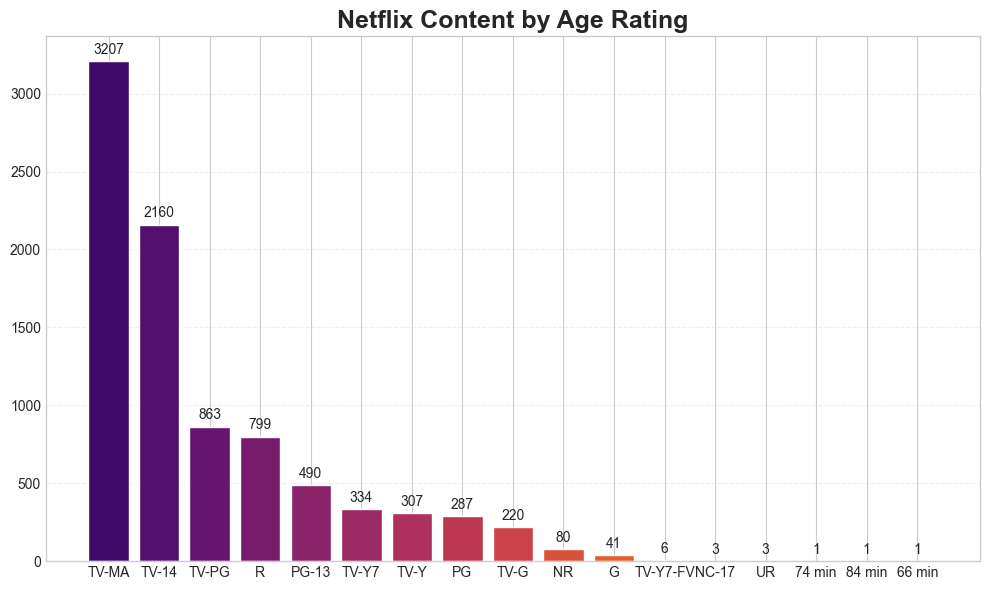

In [106]:
ratings = (
    df[df['rating'] != 'Unknown']['rating'].value_counts()
)
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(
    ratings.index,
    ratings.values,
    color=cm.inferno(np.linspace(0.2,0.9,len(ratings))),
    edgecolor='white'
)
ax.bar_label(bars, padding=3)
ax.set_title("Netflix Content by Age Rating", fontsize=18, weight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

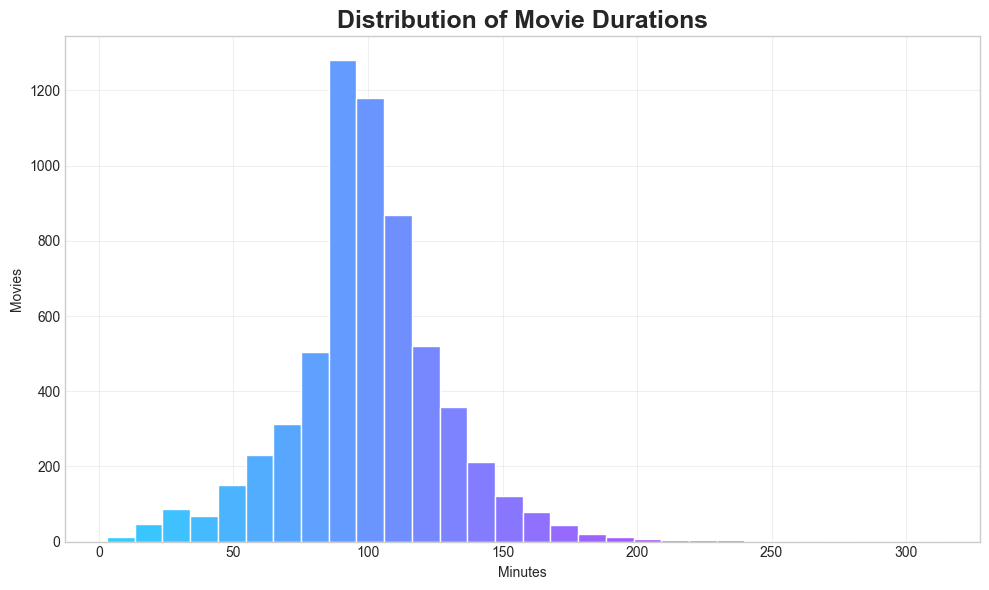

In [107]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = (
    movies['duration'].str.replace(' min', '', regex=False).astype(float)
)
fig, ax = plt.subplots(figsize=(10,6))
n, bins, patches = ax.hist(
    movies['duration_mins'],
    bins=30,
    edgecolor='white'
)
for patch, color in zip(
    patches,
    cm.cool(np.linspace(0.2,0.9,len(patches)))
):
    patch.set_facecolor(color)
ax.set_title("Distribution of Movie Durations", fontsize=18, weight='bold')
ax.set_xlabel("Minutes")
ax.set_ylabel("Movies")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

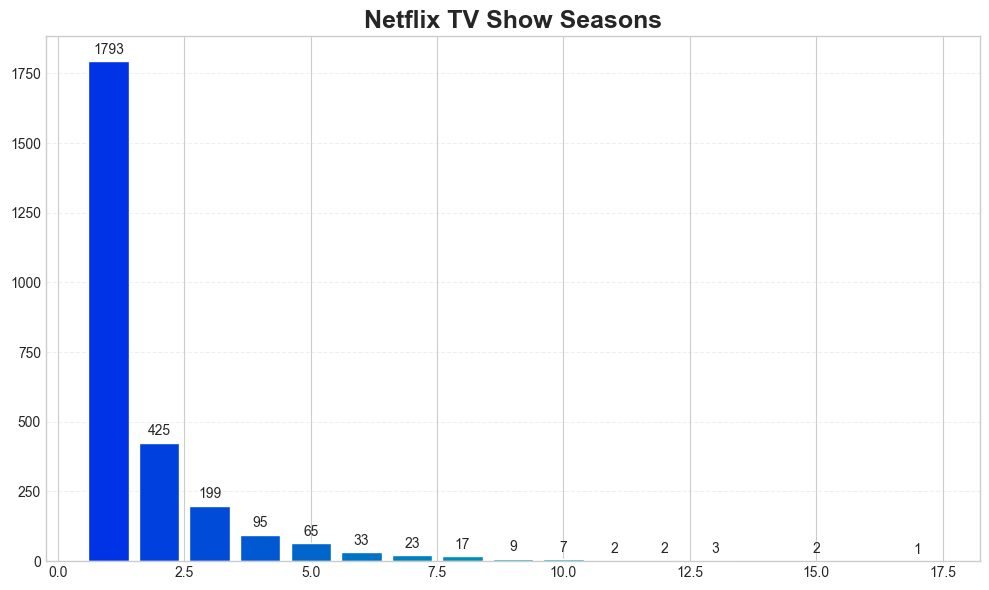

In [108]:
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = (
    shows['duration'].str.replace(' Season', '', regex=False).str.replace('s', '', regex=False).astype(float)
)
season_counts = shows['seasons'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(
    season_counts.index.astype(int),
    season_counts.values,
    color=cm.winter(np.linspace(0.2,0.9,len(season_counts))),
    edgecolor='white'
)
ax.bar_label(bars, padding=3)
ax.set_title("Netflix TV Show Seasons", fontsize=18, weight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

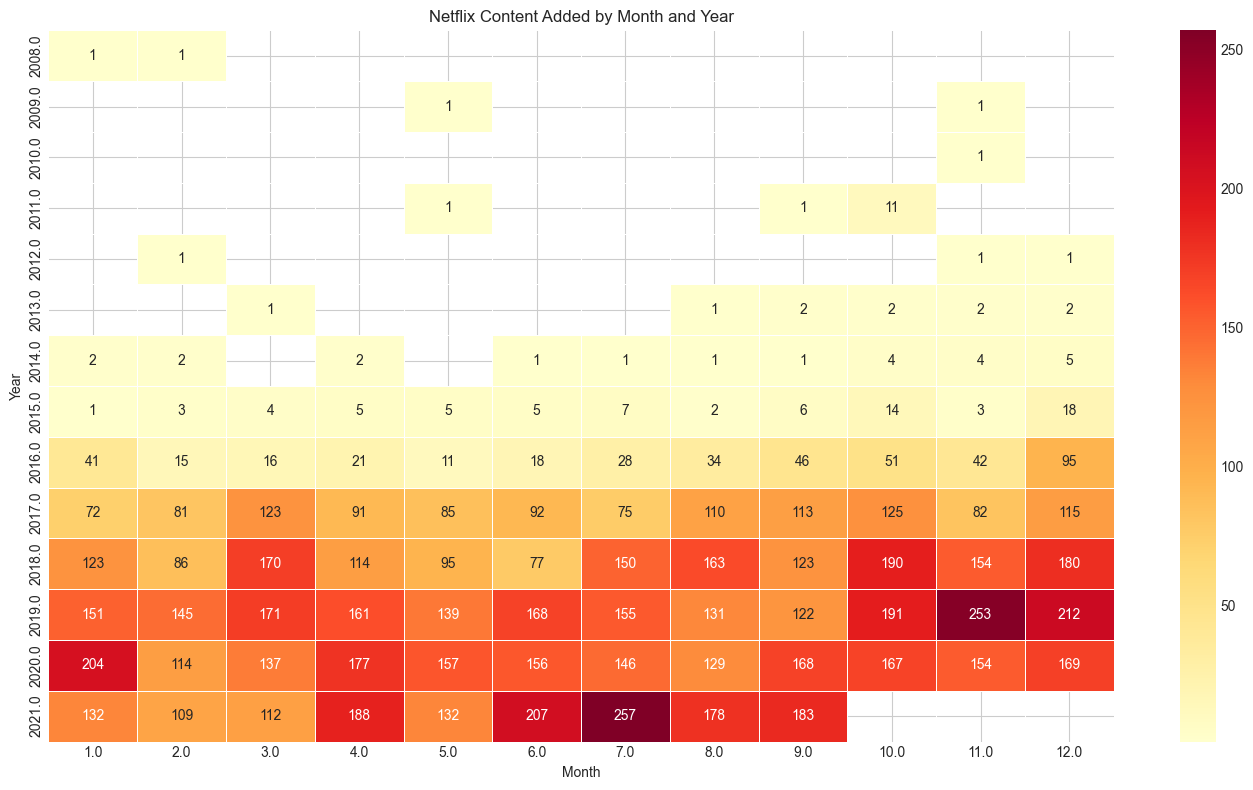

In [109]:

pivot = df.groupby(['year_added', 'month_added'])['title'].count().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, 
            cmap='YlOrRd',
            linewidths=0.5,
            annot=True,
            fmt='g')

plt.title('Netflix Content Added by Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('heatmap_monthly.png')
plt.show()

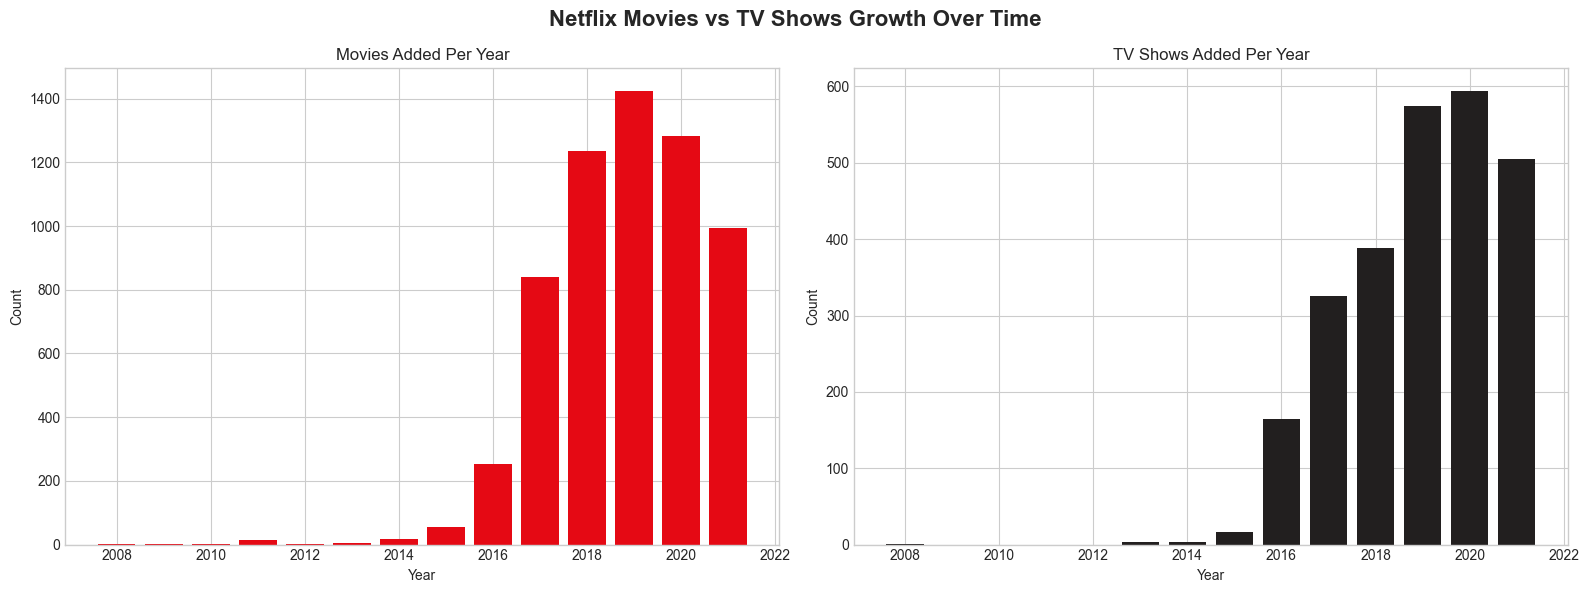

In [110]:

movies_by_year = df[df['type'] == 'Movie'].groupby('year_added')['title'].count()
shows_by_year = df[df['type'] == 'TV Show'].groupby('year_added')['title'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movies
ax1.bar(movies_by_year.index, movies_by_year.values, color='#E50914')
ax1.set_title('Movies Added Per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')

# TV Shows
ax2.bar(shows_by_year.index, shows_by_year.values, color='#221F1F')
ax2.set_title('TV Shows Added Per Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Count')

plt.suptitle('Netflix Movies vs TV Shows Growth Over Time', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('movies_vs_shows_growth.png')
plt.show()